# Geometrik & Spatial Filtering

Praktikum: Operasi Geometrik & Spatial Filtering

Notebook ini mendemonstrasikan operasi geometrik (scaling, rotation, flipping) dan spatial filtering (mean, gaussian, sharpening) menggunakan Python + OpenCV. Jalankan sel satu-persatu. Jika tidak memiliki `data/lenna.png`, notebook akan menggunakan gambar fallback dari `skimage.data`.

## 1. Setup environment
Jika library belum terpasang, jalankan perintah pip di bawah ini. (Uncomment baris pip jika perlu)

In [13]:
# Jika perlu, jalankan ini sekali untuk memasang dependency
# pip install --quiet opencv-python matplotlib scikit-image numpy

print("Pastikan opencv-python, matplotlib, scikit-image, numpy sudah terinstall.")


Pastikan opencv-python, matplotlib, scikit-image, numpy sudah terinstall.


## 2. Load image
Notebook mencoba memuat `data/lenna.png`. Jika tidak ada, gunakan gambar fallback dari `skimage.data`.

Using image: Assets/data/lenna.png


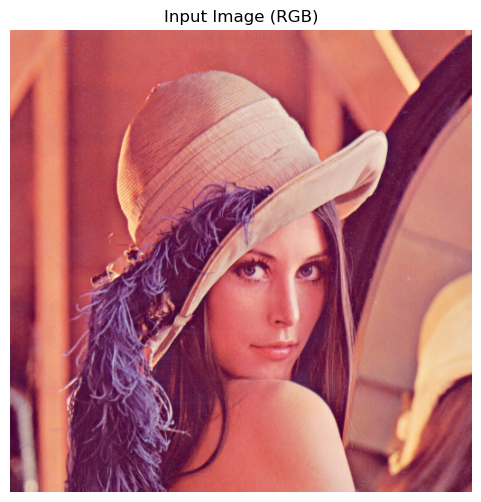

In [14]:
import os
import cv2
import numpy as np
from skimage import data, img_as_ubyte
import matplotlib.pyplot as plt

local_path = "Assets/data/lenna.png"
if os.path.exists(local_path):
    img_bgr = cv2.imread(local_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    source = local_path
else:
    img_gray = img_as_ubyte(data.camera())
    img_rgb = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2RGB)
    img_bgr = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR)
    source = "skimage.data.camera() (fallback)"

print("Using image:", source)
plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
plt.title("Input Image (RGB)")
plt.axis('off')
plt.show()


## 3. Scaling (Resize)
Contoh: scaling up (fx=1.5, fy=1.5) dan scaling down (fx=0.5, fy=0.5).

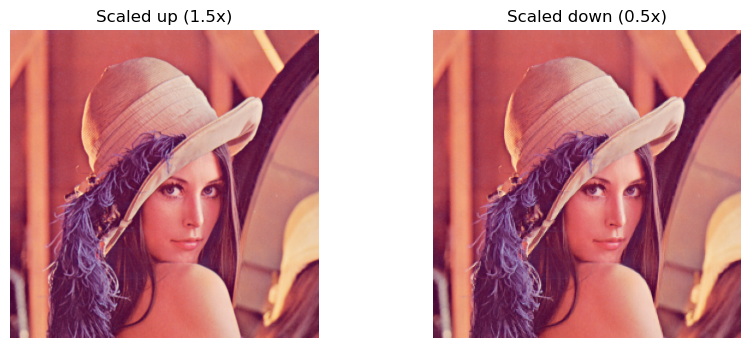

In [15]:
# Scaling examples
scaled_up = cv2.resize(img_rgb, None, fx=1.5, fy=1.5, interpolation=cv2.INTER_LINEAR)
scaled_down = cv2.resize(img_rgb, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(scaled_up); plt.title('Scaled up (1.5x)'); plt.axis('off')
plt.subplot(1,2,2); plt.imshow(scaled_down); plt.title('Scaled down (0.5x)'); plt.axis('off')
plt.show()


## 4. Rotation
Putar citra 45° terhadap pusatnya menggunakan `cv2.getRotationMatrix2D` dan `cv2.warpAffine`. Juga tunjukkan rotasi dengan padding agar seluruh gambar terlihat.

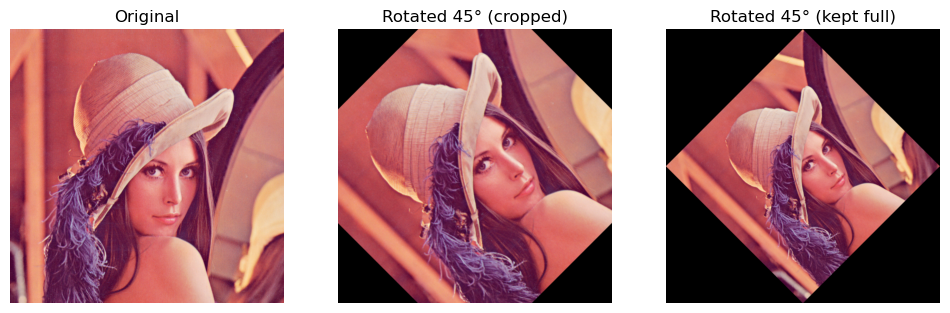

In [16]:
(h, w) = img_rgb.shape[:2]
angle = 45
scale = 1.0

# Rotation around center (may crop corners)
M = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
rotated = cv2.warpAffine(img_rgb, M, (w, h))

# Rotation with bounding to keep full image (compute new size)
import math
cos = abs(math.cos(math.radians(angle)))
sin = abs(math.sin(math.radians(angle)))
new_w = int(h * sin + w * cos)
new_h = int(h * cos + w * sin)

# adjust matrix to take into account translation
M2 = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
M2[0,2] += (new_w - w) / 2
M2[1,2] += (new_h - h) / 2
rotated_full = cv2.warpAffine(img_rgb, M2, (new_w, new_h))

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(img_rgb); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(rotated); plt.title('Rotated 45° (cropped)'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(rotated_full); plt.title('Rotated 45° (kept full)'); plt.axis('off')
plt.show()


## 5. Flipping
Flip horizontal, vertical, dan both axes menggunakan `cv2.flip`.

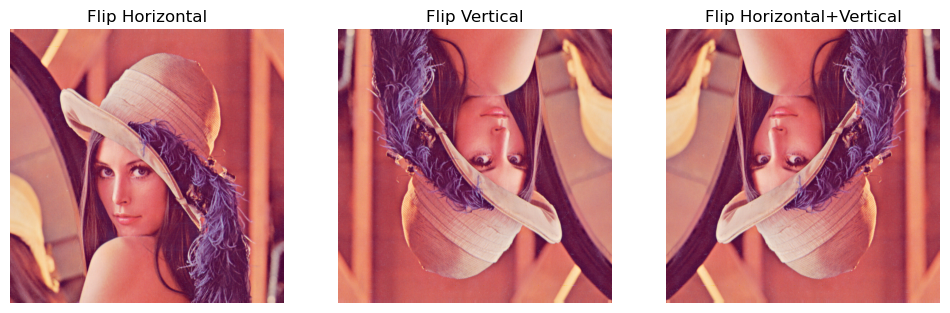

In [17]:
flip_h = cv2.flip(img_rgb, 1)   # horizontal
flip_v = cv2.flip(img_rgb, 0)   # vertical
flip_hv = cv2.flip(img_rgb, -1) # both

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(flip_h); plt.title('Flip Horizontal'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(flip_v); plt.title('Flip Vertical'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(flip_hv); plt.title('Flip Horizontal+Vertical'); plt.axis('off')
plt.show()


## 6. Spatial Filtering (Konvolusi)
Filtering = operasi konvolusi antara citra dan kernel. Kita akan praktekkan mean (average), gaussian, dan sharpening filter.

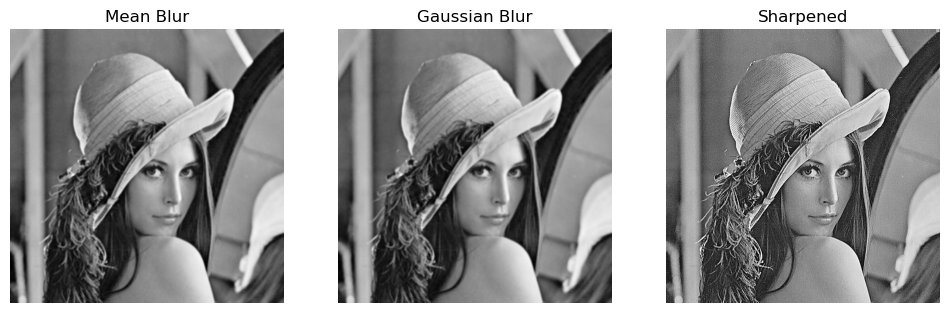

In [18]:
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Mean filter (average)
mean_blur = cv2.blur(img_gray, (3,3))

# Gaussian filter
gaussian_blur = cv2.GaussianBlur(img_gray, (5,5), 0)

# Sharpening (custom kernel)
kernel_sharp = np.array([[0, -1, 0],
                         [-1, 5,-1],
                         [0, -1, 0]])
sharpen = cv2.filter2D(img_gray, -1, kernel_sharp)

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(mean_blur, cmap='gray'); plt.title('Mean Blur'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(gaussian_blur, cmap='gray'); plt.title('Gaussian Blur'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(sharpen, cmap='gray'); plt.title('Sharpened'); plt.axis('off')
plt.show()


## 7. Kernel Examples & Edge Detectors
Tampilkan kernel Sobel dan aplikasikan Sobel X/Y untuk perbandingan (tambahan kecil berkaitan dengan edge detection).

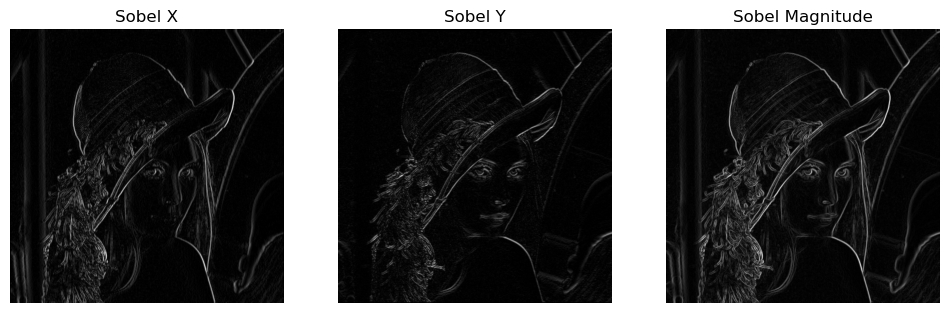

In [19]:
# Sobel kernels are applied via cv2.Sobel
sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=3)
sobel_mag = cv2.magnitude(sobelx, sobely)
sobel_mag_norm = cv2.normalize(sobel_mag, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(np.abs(sobelx), cmap='gray'); plt.title('Sobel X'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(np.abs(sobely), cmap='gray'); plt.title('Sobel Y'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(sobel_mag_norm, cmap='gray'); plt.title('Sobel Magnitude'); plt.axis('off')
plt.show()


## 8. Preprocessing untuk Deteksi
Contoh pipeline: resize -> rotate -> gaussian blur -> sobel untuk pra-pemrosesan sebelum ekstraksi fitur atau segmentasi.

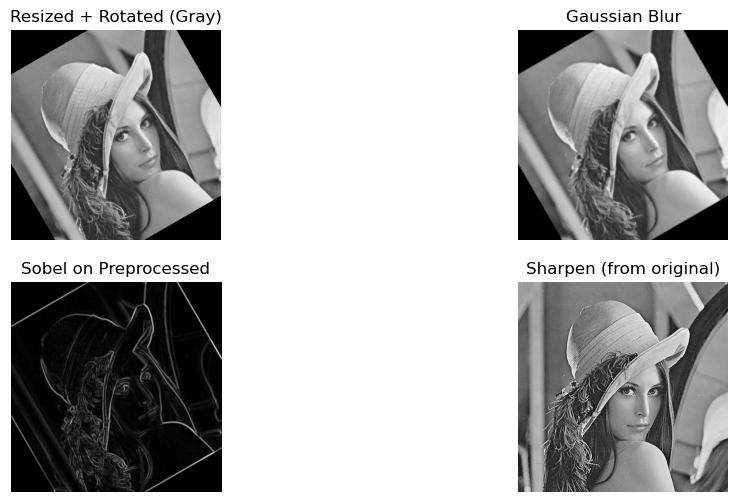

In [20]:
# Pipeline example
proc = cv2.resize(img_rgb, (512, 512))
(hp, wp) = proc.shape[:2]
M = cv2.getRotationMatrix2D((wp/2, hp/2), 30, 1.0)
proc = cv2.warpAffine(proc, M, (wp, hp))
proc_gray = cv2.cvtColor(proc, cv2.COLOR_RGB2GRAY)
proc_blur = cv2.GaussianBlur(proc_gray, (5,5), 0)
proc_sobel = cv2.Sobel(proc_blur, cv2.CV_64F, 1, 0, ksize=3)
proc_sobel_mag = cv2.magnitude(proc_sobel, cv2.Sobel(proc_blur, cv2.CV_64F, 0, 1, ksize=3))
proc_sobel_norm = cv2.normalize(proc_sobel_mag, None, 0, 255, cv2.NORM_MINMAX).astype('uint8')

plt.figure(figsize=(12,6))
plt.subplot(2,2,1); plt.imshow(cv2.cvtColor(proc, cv2.COLOR_RGB2GRAY), cmap='gray'); plt.title('Resized + Rotated (Gray)'); plt.axis('off')
plt.subplot(2,2,2); plt.imshow(proc_blur, cmap='gray'); plt.title('Gaussian Blur'); plt.axis('off')
plt.subplot(2,2,3); plt.imshow(proc_sobel_norm, cmap='gray'); plt.title('Sobel on Preprocessed'); plt.axis('off')
plt.subplot(2,2,4); plt.imshow(sharpen, cmap='gray'); plt.title('Sharpen (from original)'); plt.axis('off')
plt.show()


## 9. Latihan / Tugas
1. Ubah faktor scaling dan bandingkan hasil interpolasi (INTER_LINEAR vs INTER_AREA vs INTER_CUBIC).
2. Eksperimen dengan sudut rotasi berbeda dan perhatikan perbedaan cropping vs keeping full image.
3. Ubah kernel sharpening dan bandingkan efek pada detail.
4. Gabungkan transformasi geometrik dan filtering untuk meningkatkan hasil deteksi tepi pada citra noisy.

### 1. Perbandingan Interpolasi Scaling

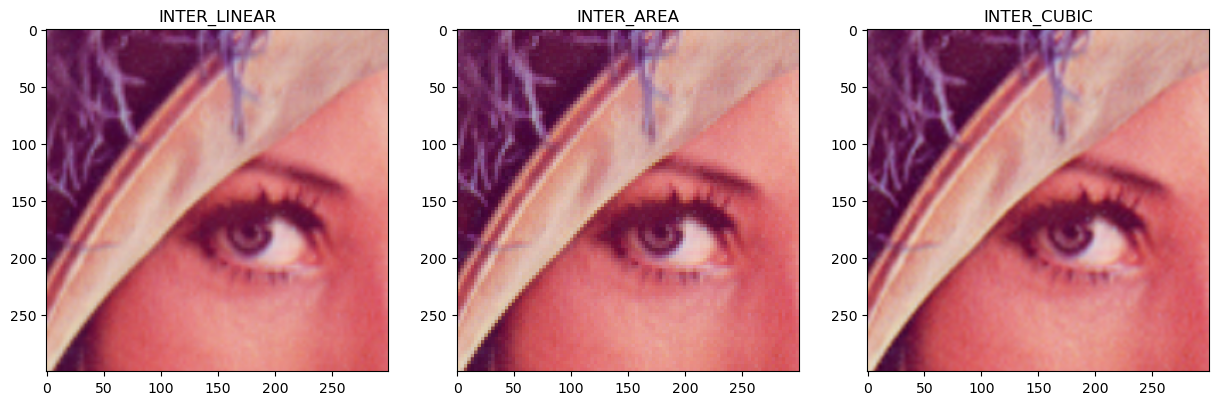

In [21]:
scale_factor = 3.0
dim = None # Biarkan OpenCV menghitung dimensi berdasarkan fx, fy

# 1. Linear (Default)
up_linear = cv2.resize(img_rgb, dim, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_LINEAR)

# 2. Area (Biasanya untuk mengecilkan, tapi kita coba untuk perbandingan)
up_area = cv2.resize(img_rgb, dim, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_AREA)

# 3. Cubic (Lebih lambat, tapi hasil lebih halus untuk perbesaran)
up_cubic = cv2.resize(img_rgb, dim, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_CUBIC)

# Visualisasi (Zoom in ke bagian mata/wajah agar perbedaan terlihat)
# Kita crop bagian tengah hasil resize
h, w = up_linear.shape[:2]
cy, cx = h//2, w//2
crop_s = 150 # ukuran crop

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1); plt.imshow(up_linear[cy-crop_s:cy+crop_s, cx-crop_s:cx+crop_s]); plt.title('INTER_LINEAR')
plt.subplot(1,3,2); plt.imshow(up_area[cy-crop_s:cy+crop_s, cx-crop_s:cx+crop_s]); plt.title('INTER_AREA')
plt.subplot(1,3,3); plt.imshow(up_cubic[cy-crop_s:cy+crop_s, cx-crop_s:cx+crop_s]); plt.title('INTER_CUBIC')
plt.show()

Analisis Singkat:
- INTER_LINEAR: Hasil standar, cukup halus tetapi terkadang garis tepi terlihat agak kabur.
- INTER_AREA: Metode ini didesain untuk downscaling (mengecilkan). Jika dipakai untuk memperbesar, hasilnya mirip Nearest Neighbor (kotak-kotak/pixelated).
- INTER_CUBIC: Menghasilkan garis tepi yang lebih tajam dan halus dibanding Linear, sangat bagus untuk memperbesar foto, namun komputasinya lebih berat.

### 2. Eksperimen Rotasi (Full vs Cropped)

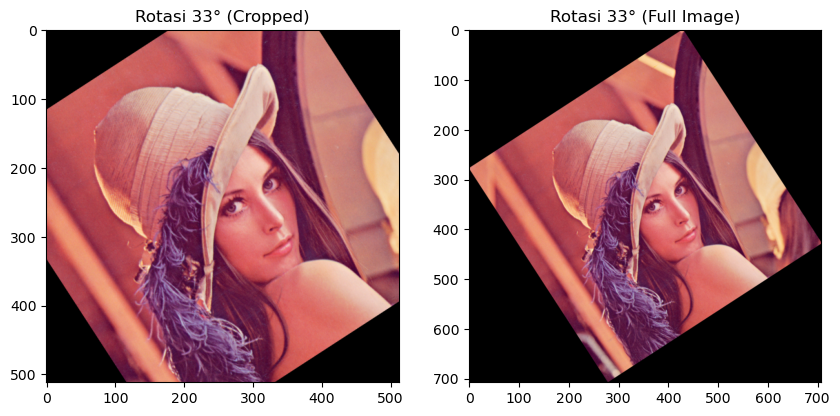

In [22]:
angle = 33 # Sudut eksperimen
scale = 1.0
(h, w) = img_rgb.shape[:2]

# --- A. Rotasi Biasa (Cropped) ---
M = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
rotated_crop = cv2.warpAffine(img_rgb, M, (w, h))

# --- B. Rotasi Full (Tanpa Terpotong) ---
# Hitung bounding box baru
import math
cos = abs(math.cos(math.radians(angle)))
sin = abs(math.sin(math.radians(angle)))
new_w = int(h * sin + w * cos)
new_h = int(h * cos + w * sin)

# Sesuaikan matriks transformasi (geser pusat)
M_full = cv2.getRotationMatrix2D((w/2, h/2), angle, scale)
M_full[0, 2] += (new_w - w) / 2
M_full[1, 2] += (new_h - h) / 2

rotated_full = cv2.warpAffine(img_rgb, M_full, (new_w, new_h))

plt.figure(figsize=(10, 5))
plt.subplot(1,2,1); plt.imshow(rotated_crop); plt.title(f'Rotasi {angle}° (Cropped)')
plt.subplot(1,2,2); plt.imshow(rotated_full); plt.title(f'Rotasi {angle}° (Full Image)')
plt.show()

Analisis Singkat:
- Cropped: Pojok-pojok gambar asli hilang (terpotong hitam) karena dimensi canvas tetap sama dengan gambar asli.
- Full: Seluruh bagian gambar asli terlihat, tetapi dimensi citra output menjadi lebih besar (resolusi bertambah) untuk memuat sudut-sudut yang miring.

### 3. Variasi Kernel Sharpening

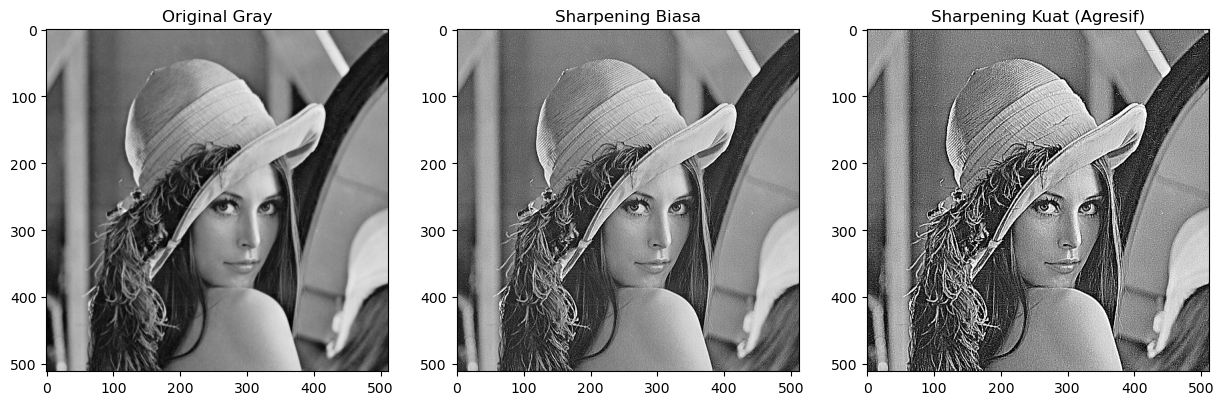

In [23]:
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

# Kernel 1: Sharpening Halus
kernel_1 = np.array([[0, -1, 0],
                     [-1, 5,-1],
                     [0, -1, 0]])

# Kernel 2: Sharpening Kuat (Diagonal juga ikut dihitung)
kernel_2 = np.array([[-1, -1, -1],
                     [-1,  9, -1],
                     [-1, -1, -1]])

# Terapkan filter
sharp_1 = cv2.filter2D(img_gray, -1, kernel_1)
sharp_2 = cv2.filter2D(img_gray, -1, kernel_2)

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1); plt.imshow(img_gray, cmap='gray'); plt.title('Original Gray')
plt.subplot(1,3,2); plt.imshow(sharp_1, cmap='gray'); plt.title('Sharpening Biasa')
plt.subplot(1,3,3); plt.imshow(sharp_2, cmap='gray'); plt.title('Sharpening Kuat (Agresif)')
plt.show()

Analisis Singkat:
- Kernel Biasa: Mempertegas tepi tapi masih menjaga tekstur alami.
- Kernel Kuat: Detail menjadi sangat tajam, namun noise (bintik-bintik) pada gambar juga akan ikut "dipertajam" sehingga gambar terlihat kotor/kasar.

### 4. Kombinasi Geometrik & Filtering pada Noisy Image

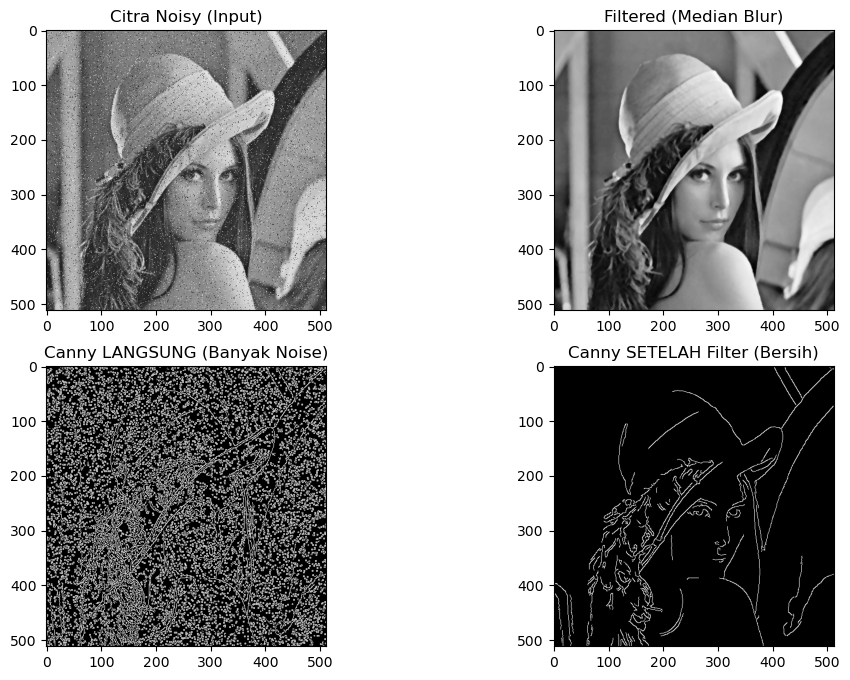

In [24]:
# 1. Buat Citra Noisy (Simulasi)
from skimage.util import random_noise
noise_img = random_noise(img_gray, mode='s&p', amount=0.05) # Salt & Pepper noise
noise_img = np.array(255*noise_img, dtype='uint8')

# --- SKENARIO A: Tanpa Filtering (Langsung Deteksi Tepi) ---
edges_bad = cv2.Canny(noise_img, 100, 200)

# --- SKENARIO B: Dengan Pipeline (Blur -> Resize -> Edge) ---
# Langkah 1: Hapus noise dengan Median Blur (bagus untuk salt & pepper) atau Gaussian
denoised = cv2.medianBlur(noise_img, 5)

# Langkah 2: Resize (opsional, kadang mengecilkan gambar menyembunyikan noise)
# Kita lewati resize agar perbandingan apple-to-apple, fokus ke filtering

# Langkah 3: Deteksi Tepi
edges_good = cv2.Canny(denoised, 100, 200)

plt.figure(figsize=(12, 8))
plt.subplot(2,2,1); plt.imshow(noise_img, cmap='gray'); plt.title('Citra Noisy (Input)')
plt.subplot(2,2,2); plt.imshow(denoised, cmap='gray'); plt.title('Filtered (Median Blur)')
plt.subplot(2,2,3); plt.imshow(edges_bad, cmap='gray'); plt.title('Canny LANGSUNG (Banyak Noise)')
plt.subplot(2,2,4); plt.imshow(edges_good, cmap='gray'); plt.title('Canny SETELAH Filter (Bersih)')
plt.show()

Analisis Singkat:
- Jika kita menerapkan deteksi tepi (Canny/Sobel) langsung pada citra yang noisy, setiap bintik noise akan dianggap sebagai "tepi" (edge), menghasilkan gambar yang penuh sampah putih.
- Dengan menerapkan Spatial Filtering (seperti Gaussian Blur atau Median Blur) terlebih dahulu, kita menghaluskan noise tersebut. Akibatnya, detektor tepi hanya akan menangkap garis kontur utama objek, menghasilkan output yang jauh lebih bersih dan bermakna.